# Chapter 60: Multi-Target Learning

**When does a dense auxiliary target improve a scarce main target on new rows, and how much does the loss weight matter?**

Adding targets is cheap and tempting, but the chapter's rule is to compare the primary metric with and without the auxiliary task under a fixed budget. The size and sign of the change depend on how related the tasks are and on the weight, and a single run can mislead either way.

*Constructed data. The gains are properties of this generator and of 12 replicates; the unrelated-task result is small and within noise, so the activity reports no reliable harm from an unrelated auxiliary task.*

## The experiment

Twelve constructed problems, each with its own latent structure. The main target has only 120 labelled rows; the auxiliary target has 1,200. Both are nonlinear functions of the same ten inputs. The auxiliary target mixes a signal built on the main target's latent features (the same hidden directions, read out differently) with an unrelated signal; the control is the weight on the shared part (1.0 means entirely built on the shared features, 0 means an unrelated signal). A shared tanh layer of 12 units with one linear head per target is trained on the loss main MSE + w * auxiliary MSE, for w in 0 (single-task), 0.3, 1 and 3. Every model stops at the step that scores best on 30 held-back main-label rows, then is scored by R-squared on 4,000 new rows.

In [1]:
import numpy as np

from kaggle_companion.activities._common import clean

SEED = 60
PROBLEMS, DRAWS = 12, 1     # 12 problems, each with its own latent structure and data draw: independent replicates
REPLICATES = PROBLEMS * DRAWS
D, HIDDEN = 10, 12          # input features and shared hidden units
N_MAIN, N_AUX, N_TEST = 120, 1200, 4000
N_FIT = 90                  # of the 120 main labels: 90 fit the network, 30 choose the stopping step
WEIGHTS = [0.0, 0.3, 1.0, 3.0]   # auxiliary loss weight; 0 is the single-task model
STEPS, LR, DECAY, CHECK_EVERY = 400, 0.01, 0.01, 25


def generate(relatedness, problem_seed, data_seed):
    """One problem: its latent structure comes from `problem_seed`, its rows from `data_seed`. Both targets are
    nonlinear functions of the same inputs. The main target reads the latent features tanh(X A). The auxiliary
    target is `relatedness` parts a different readout of the same features and the rest an unrelated signal v. Main labels are scarce (120 rows); auxiliary
    labels are dense (1,200 rows)."""
    prob = np.random.default_rng(problem_seed)
    A, B = prob.normal(size=(D, 3)), prob.normal(size=(D, 3))
    c_main, c_other, c_aux = prob.normal(size=(3, 3))
    probe = prob.normal(size=(5000, D))
    scale = [(np.tanh(probe @ A) @ c_main).std(), (np.tanh(probe @ B) @ c_other).std(), (np.tanh(probe @ A) @ c_aux).std()]
    rng = np.random.default_rng(data_seed)

    def rows(n):
        X = rng.normal(size=(n, D))
        u_main = np.tanh(X @ A) @ c_main / scale[0]
        v = np.tanh(X @ B) @ c_other / scale[1]
        u_aux = np.tanh(X @ A) @ c_aux / scale[2]
        y_main = u_main + rng.normal(0, 0.5, n)
        y_aux = relatedness * u_aux + np.sqrt(1 - relatedness ** 2) * v + rng.normal(0, 0.3, n)
        return X, y_main, y_aux
    return rows(N_MAIN), rows(N_AUX), rows(N_TEST)


def r2(y, pred):
    return 1 - ((y - pred) ** 2).sum() / ((y - y.mean()) ** 2).sum()


def fit_multitask(X_fit, y_fit, X_val, y_val, X_aux, y_aux, weight, seed, X_test):
    """Shared tanh layer, one linear head per target. Loss = main MSE + weight * auxiliary MSE, trained with Adam.
    The step is chosen by the main-label validation rows, exactly as for a single-task model; returns the
    test predictions at that step."""
    rng = np.random.default_rng(seed)
    P = {"W": rng.normal(0, 0.5, (D, HIDDEN)), "b": np.zeros(HIDDEN), "head_main": rng.normal(0, 0.3, HIDDEN),
         "head_aux": rng.normal(0, 0.3, HIDDEN), "c_main": np.zeros(1), "c_aux": np.zeros(1)}
    m1 = {k: np.zeros_like(v) for k, v in P.items()}
    m2 = {k: np.zeros_like(v) for k, v in P.items()}
    best_score, best_pred = -np.inf, None
    for t in range(1, STEPS + 1):
        H = np.tanh(X_fit @ P["W"] + P["b"])
        e = (H @ P["head_main"] + P["c_main"] - y_fit) / len(y_fit)          # main error signal
        g = {"head_main": H.T @ e, "c_main": e.sum(keepdims=True)}
        dH = np.outer(e, P["head_main"]) * (1 - H ** 2)
        g["W"], g["b"] = X_fit.T @ dH, dH.sum(0)
        if weight > 0:                                                         # auxiliary gradient joins the shared layer
            Ha = np.tanh(X_aux @ P["W"] + P["b"])
            ea = weight * (Ha @ P["head_aux"] + P["c_aux"] - y_aux) / len(y_aux)
            g["head_aux"], g["c_aux"] = Ha.T @ ea, ea.sum(keepdims=True)
            dHa = np.outer(ea, P["head_aux"]) * (1 - Ha ** 2)
            g["W"], g["b"] = g["W"] + X_aux.T @ dHa, g["b"] + dHa.sum(0)
        else:
            g["head_aux"], g["c_aux"] = np.zeros(HIDDEN), np.zeros(1)
        g["W"] = g["W"] + DECAY * P["W"]
        for k in P:                                                            # Adam update
            m1[k] = 0.9 * m1[k] + 0.1 * g[k]
            m2[k] = 0.999 * m2[k] + 0.001 * g[k] ** 2
            P[k] = P[k] - LR * (m1[k] / (1 - 0.9 ** t)) / (np.sqrt(m2[k] / (1 - 0.999 ** t)) + 1e-8)
        if t % CHECK_EVERY == 0:
            score = r2(y_val, np.tanh(X_val @ P["W"] + P["b"]) @ P["head_main"] + P["c_main"])
            if score > best_score:
                best_score = score
                best_pred = np.tanh(X_test @ P["W"] + P["b"]) @ P["head_main"] + P["c_main"]
    return best_pred


def run(relatedness):
    scores = {w: [] for w in WEIGHTS}
    for i in range(REPLICATES):
        problem, draw = divmod(i, DRAWS)
        (Xm, ym, _), (Xa, _, ya), (Xt, yt, _) = generate(relatedness, SEED * 100 + problem, SEED * 1000 + i)
        for w in WEIGHTS:
            pred = fit_multitask(Xm[:N_FIT], ym[:N_FIT], Xm[N_FIT:], ym[N_FIT:], Xa, ya, w, i, Xt)
            scores[w].append(r2(yt, pred))                                      # R2 on 4,000 fresh rows
    base = np.array(scores[0.0])
    gain = {w: np.array(scores[w]) - base for w in WEIGHTS}
    return clean({
        "relatedness": relatedness, "weights": WEIGHTS,
        "r2": {str(w): float(np.mean(scores[w])) for w in WEIGHTS},
        "per_replicate": {str(w): scores[w] for w in WEIGHTS},
        "gain": {str(w): float(gain[w].mean()) for w in WEIGHTS},
        "gain_se": {str(w): float(gain[w].std(ddof=1) / np.sqrt(REPLICATES)) for w in WEIGHTS},
        "gain_per_replicate": {str(w): gain[w] for w in WEIGHTS},
        "share_better": {str(w): float(np.mean(gain[w] > 0)) for w in WEIGHTS},
        "replicates": REPLICATES, "main_labels": N_MAIN, "auxiliary_labels": N_AUX, "test_rows": N_TEST,
    })


## Measure it across the control

The control is **relatedness of the auxiliary target (share of its signal built on the main target's latent features)**. Each value below runs the whole experiment from the generator up.

In [2]:
import pandas as pd
from kaggle_companion.activities.ch60 import explain

VALUES = [1.0, 0.7, 0.3, 0.0]
results = {value: run(value) for value in VALUES}
table = pd.DataFrame({str(v): explain(results[v], v)['metrics'] for v in VALUES})
print(table.to_string())

                                         1.0     0.7     0.3     0.0
Single-task R-squared                  0.574   0.574   0.574   0.574
R-squared at weight 0.3                0.601   0.594   0.590   0.587
R-squared at weight 1                  0.619   0.604   0.585   0.572
R-squared at weight 3                  0.653   0.657   0.590   0.570
Gain at weight 3                      +0.079  +0.083  +0.016  -0.004
Gain at weight 3, in standard errors     5.8     4.7     1.0    -0.2


## Look at it

The figure shows the default setting, relatedness of the auxiliary target (share of its signal built on the main target's latent features) = 0.7.

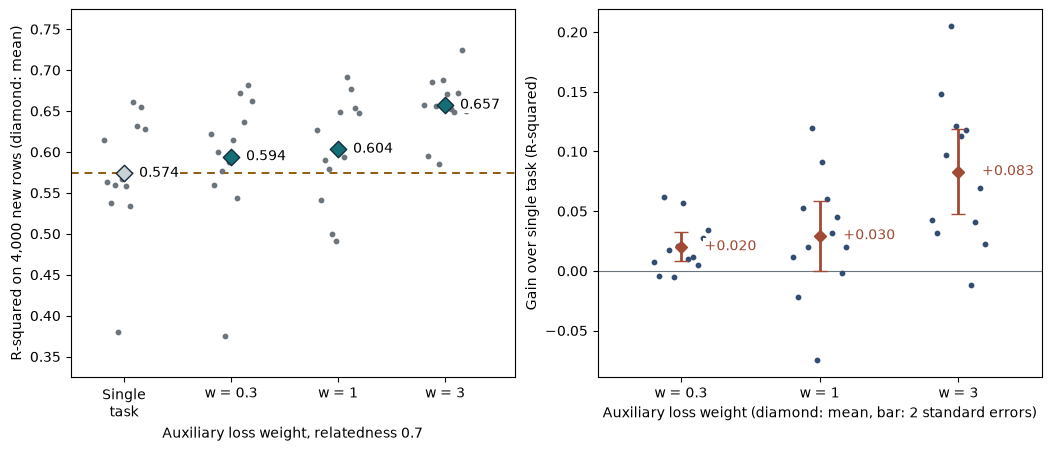

In [3]:
import matplotlib.pyplot as plt
from kaggle_companion.activities.ch60 import draw, NCOLS, HEIGHT

DEFAULT = 0.7
fig, axes = plt.subplots(1, NCOLS, figsize=(6.6 if NCOLS == 1 else 10.4, HEIGHT), layout='constrained')
draw(axes, results[DEFAULT], DEFAULT)
plt.show()

## What the result says

At relatedness 0.7 the single-task model scores R-squared 0.574 on new rows. With the auxiliary task at weight 3 it scores 0.657, and 0.657 - 0.574 = 0.083 (standard error 0.018, better in 92% of 12 replicates). The gain is more than two standard errors, so the auxiliary task earns its place. Weight 1 changes the score by +0.030 and weight 0.3 by +0.020.

- Single-task model: R-squared 0.574 on 4,000 new rows.
- Weight 3: 0.657 - 0.574 = 0.083, with standard error 0.018.
- Weight 1: 0.604 - 0.574 = 0.030.
- Weight 0.3: 0.594 - 0.574 = 0.020.

## Apply this to your competition

- Train a single-task reference with the same stopping rule and budget before adding any auxiliary target.
- Compare the primary metric alone on rows neither model used, and keep per-target results visible rather than only an average.
- Prefer auxiliary targets that share latent structure with the primary target and have denser labels than the primary target.
- Treat the auxiliary loss weight as a hyperparameter: raise it only while the primary metric keeps improving, and expect a flat or negative change when the tasks are weakly related.

Book location: Chapter 60, Auxiliary Tasks: What Qualifies.

[Technical corrections](https://github.com/KarpelesPublishing/winning-kaggle-companion/blob/main/docs/errata.md)